# CIFAR-10 Classification with SIFT Feature Extraction and FCNN

In this notebook, I test a classical feature extraction approach before using CNNs.

Last week, I used an FCNN directly on CIFAR-10 raw pixel values.  
In this experiment, I first extract SIFT features from CIFAR-10 images and then use these features as input to an FCNN.

The goal is to see whether handcrafted SIFT features can improve FCNN performance on a more complex image dataset.

In [1]:
!pip install opencv-contrib-python scikit-learn -q

import cv2
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

from sklearn.cluster import MiniBatchKMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

np.random.seed(42)
tf.random.set_seed(42)

print("TensorFlow version:", tf.__version__)
print("OpenCV version:", cv2.__version__)

TensorFlow version: 2.20.0
OpenCV version: 4.13.0


## 1. Load CIFAR-10 Dataset

CIFAR-10 contains 60,000 small RGB images from 10 object classes.

Each image has size 32 × 32 × 3.

Compared with MNIST, CIFAR-10 is more difficult because the images contain color, texture, background variation, and more complex object shapes.

In [2]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

y_train = y_train.reshape(-1)
y_test = y_test.reshape(-1)

class_names = ["airplane", "automobile", "bird", "cat", "deer","dog", "frog", "horse", "ship", "truck"]

print("Training images:", x_train.shape)
print("Test images:", x_test.shape)
print("Training labels:", y_train.shape)
print("Test labels:", y_test.shape)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 3811s 22us/step
Training images: (50000, 32, 32, 3)
Test images: (10000, 32, 32, 3)
Training labels: (50000,)
Test labels: (10000,)


# Show Example CIFAR-10 Images

CIFAR-10 images are small RGB images.

They are more complex than MNIST because they include color, background variation, texture, and different object shapes.

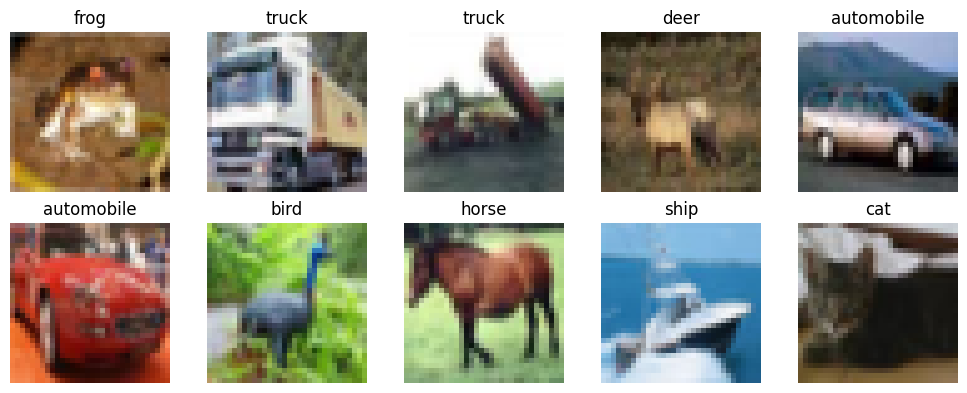

In [3]:
plt.figure(figsize=(10, 4))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_train[i])
    plt.title(class_names[y_train[i]])
    plt.axis("off")

plt.tight_layout()
plt.show()

## 2.  Configuration



In [4]:
RUN_FULL_DATASET = False

TRAIN_LIMIT = 8000
TEST_LIMIT = 2000

IMAGE_SIZE = 128
STEP_SIZE = 8

VOCAB_SIZE = 400
COLOR_BINS = 16

MAX_KMEANS_IMAGES = 8000
MAX_DESCRIPTORS_FOR_KMEANS = 300000

RANDOM_STATE = 42

np.random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)

if RUN_FULL_DATASET:
    x_train_work = x_train
    y_train_work = y_train
    x_test_work = x_test
    y_test_work = y_test
else:
    x_train_work = x_train[:TRAIN_LIMIT]
    y_train_work = y_train[:TRAIN_LIMIT]
    x_test_work = x_test[:TEST_LIMIT]
    y_test_work = y_test[:TEST_LIMIT]

print("Training set used:", x_train_work.shape)
print("Test set used:", x_test_work.shape)

Training set used: (8000, 32, 32, 3)
Test set used: (2000, 32, 32, 3)


### 3. Standard SIFT Visualization
This is only for explanation.
The model will use Dense SIFT later.

Class: frog
Number of SIFT keypoints: 48
Descriptor shape: (48, 128)


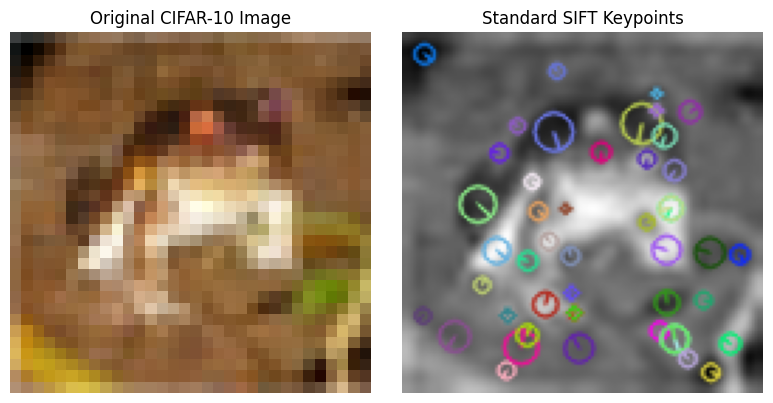

In [6]:
sift_for_visualization = cv2.SIFT_create(nfeatures=100)

def preprocess_for_sift(image_rgb, resize_to=128):
    gray = cv2.cvtColor(image_rgb, cv2.COLOR_RGB2GRAY)
    gray = cv2.resize(gray, (resize_to, resize_to), interpolation=cv2.INTER_CUBIC)
    return gray

sample_index = 0

image_rgb = x_train[sample_index]
gray = preprocess_for_sift(image_rgb)

keypoints, descriptors = sift_for_visualization.detectAndCompute(gray, None)

sift_image = cv2.drawKeypoints(
    gray,
    keypoints,
    None,
    flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS
)

print("Class:", class_names[y_train[sample_index]])
print("Number of SIFT keypoints:", len(keypoints))
print("Descriptor shape:", None if descriptors is None else descriptors.shape)

plt.figure(figsize=(8, 4))

plt.subplot(1, 2, 1)
plt.imshow(image_rgb)
plt.title("Original CIFAR-10 Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(sift_image, cmap="gray")
plt.title("Standard SIFT Keypoints")
plt.axis("off")

plt.tight_layout()
plt.show()

## 4.  Dense SIFT Functions


In [8]:
sift = cv2.SIFT_create()

def resize_rgb_image(image_rgb, image_size=IMAGE_SIZE):
    """
    CIFAR-10 images are 32x32.
    SIFT works better after resizing to a larger image size.
    """
    return cv2.resize(
        image_rgb,
        (image_size, image_size),
        interpolation=cv2.INTER_CUBIC
    )


def dense_sift_descriptors(
    image_rgb,
    step_size=STEP_SIZE,
    image_size=IMAGE_SIZE,
    apply_resize=True
):
    """
    Extract Dense SIFT descriptors from a regular grid.

    Difference from previous SIFT + FCNN:
    - Previous method used detected keypoints.
    - Dense SIFT places keypoints regularly across the image.
    - This gives more consistent local feature extraction.
    """

    if apply_resize:
        image_rgb = resize_rgb_image(image_rgb, image_size=image_size)

    gray = cv2.cvtColor(image_rgb, cv2.COLOR_RGB2GRAY)

    h, w = gray.shape

    keypoints = []

    for y_pos in range(step_size, h, step_size):
        for x_pos in range(step_size, w, step_size):
            keypoints.append(
                cv2.KeyPoint(
                    float(x_pos),
                    float(y_pos),
                    float(step_size)
                )
            )

    keypoints, descriptors = sift.compute(gray, keypoints)

    if descriptors is None or len(descriptors) == 0:
        return np.zeros((1, 128), dtype=np.float32)

    descriptors = descriptors.astype(np.float32)

    # RootSIFT normalization
    # Step 1: L1 normalize each descriptor
    descriptors = descriptors / (descriptors.sum(axis=1, keepdims=True) + 1e-7)

    # Step 2: Square-root transform
    descriptors = np.sqrt(descriptors)

    return descriptors

## 5. Visualize Dense SIFT Keypoints



Class: frog
Number of Dense SIFT keypoints: 225


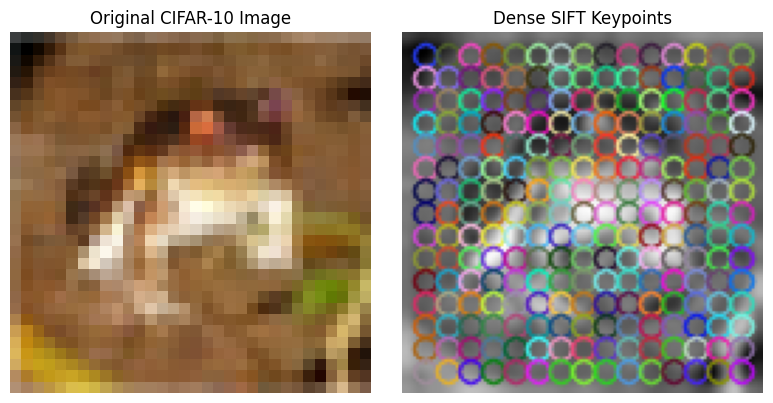

In [9]:
sample_index = 0

sample_rgb = x_train[sample_index]
sample_resized = resize_rgb_image(sample_rgb)
sample_gray = cv2.cvtColor(sample_resized, cv2.COLOR_RGB2GRAY)

sample_keypoints = []

for y_pos in range(STEP_SIZE, sample_gray.shape[0], STEP_SIZE):
    for x_pos in range(STEP_SIZE, sample_gray.shape[1], STEP_SIZE):
        sample_keypoints.append(
            cv2.KeyPoint(
                float(x_pos),
                float(y_pos),
                float(STEP_SIZE)
            )
        )

dense_sift_image = cv2.drawKeypoints(
    sample_gray,
    sample_keypoints,
    None,
    flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS
)

print("Class:", class_names[y_train[sample_index]])
print("Number of Dense SIFT keypoints:", len(sample_keypoints))

plt.figure(figsize=(8, 4))

plt.subplot(1, 2, 1)
plt.imshow(sample_rgb)
plt.title("Original CIFAR-10 Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(dense_sift_image, cmap="gray")
plt.title("Dense SIFT Keypoints")
plt.axis("off")

plt.tight_layout()
plt.show()

## 6. Build Visual Vocabulary with MiniBatchKMeans

In [10]:
def collect_descriptors_for_vocabulary(
    images,
    max_images=MAX_KMEANS_IMAGES,
    max_descriptors=MAX_DESCRIPTORS_FOR_KMEANS
):
    """
    Collect Dense SIFT descriptors from training images.
    These descriptors will be clustered into visual words.
    """

    n_images = min(len(images), max_images)

    selected_indices = np.random.choice(
        len(images),
        n_images,
        replace=False
    )

    descriptor_list = []

    for count, idx in enumerate(selected_indices, start=1):
        descriptors = dense_sift_descriptors(images[idx])
        descriptor_list.append(descriptors)

        if count % 1000 == 0:
            print(f"Collected descriptors from {count}/{n_images} images")

    all_descriptors = np.vstack(descriptor_list).astype(np.float32)

    print("Collected descriptor matrix:", all_descriptors.shape)

    if len(all_descriptors) > max_descriptors:
        sampled_indices = np.random.choice(
            len(all_descriptors),
            max_descriptors,
            replace=False
        )

        all_descriptors = all_descriptors[sampled_indices]

        print("Sampled descriptor matrix for KMeans:", all_descriptors.shape)

    return all_descriptors


print("Collecting descriptors for visual vocabulary...")

kmeans_descriptors = collect_descriptors_for_vocabulary(x_train_work)

print("Training MiniBatchKMeans visual vocabulary...")

visual_vocabulary = MiniBatchKMeans(
    n_clusters=VOCAB_SIZE,
    batch_size=4096,
    random_state=RANDOM_STATE,
    n_init=10
)

visual_vocabulary.fit(kmeans_descriptors)

print("Visual vocabulary trained.")
print("Number of visual words:", VOCAB_SIZE)

Collected descriptors from 1000/8000 images
Collected descriptors from 2000/8000 images
Collected descriptors from 3000/8000 images
Collected descriptors from 4000/8000 images
Collected descriptors from 5000/8000 images
Collected descriptors from 6000/8000 images
Collected descriptors from 7000/8000 images
Collected descriptors from 8000/8000 images
Collected descriptor matrix: (1800000, 128)
Sampled descriptor matrix for KMeans: (300000, 128)
Training MiniBatchKMeans visual vocabulary...
Visual vocabulary trained.
Number of visual words: 400


## 7.  Feature Extraction Functions
Dense SIFT + BoVW + Spatial Pyramid + Color Histogram

In [11]:
# ============================================================
# 8. Feature Extraction Functions
# Dense SIFT + BoVW + Spatial Pyramid + Color Histogram
# ============================================================

def bovw_histogram(
    descriptors,
    vocabulary_model,
    vocab_size=VOCAB_SIZE
):
    """
    Convert local SIFT descriptors into a fixed-length
    Bag-of-Visual-Words histogram.
    """

    visual_words = vocabulary_model.predict(descriptors)

    hist, _ = np.histogram(
        visual_words,
        bins=np.arange(vocab_size + 1)
    )

    hist = hist.astype(np.float32)

    # Normalize histogram
    hist = hist / (hist.sum() + 1e-7)

    return hist


def color_histogram(
    image_rgb,
    bins=COLOR_BINS,
    image_size=IMAGE_SIZE
):
    """
    Extract RGB color histogram.

    Reason:
    SIFT works on grayscale images.
    CIFAR-10 contains important color information.
    Therefore, color histogram helps restore color-based features.
    """

    image_rgb = resize_rgb_image(image_rgb, image_size=image_size)

    features = []

    for channel in range(3):
        hist = cv2.calcHist(
            [image_rgb],
            [channel],
            None,
            [bins],
            [0, 256]
        )

        hist = hist.flatten().astype(np.float32)
        hist = hist / (hist.sum() + 1e-7)

        features.extend(hist)

    return np.array(features, dtype=np.float32)


def dense_sift_spatial_feature(
    image_rgb,
    vocabulary_model,
    vocab_size=VOCAB_SIZE
):
    """
    Create one fixed-size feature vector for one image.

    Feature vector contains:
    1. Whole-image BoVW histogram
    2. 2x2 spatial pyramid BoVW histograms
    3. RGB color histogram
    """

    image_resized = resize_rgb_image(image_rgb)

    h, w, _ = image_resized.shape

    feature_parts = []

    # --------------------------------------------------------
    # Level 0: Whole image BoVW
    # --------------------------------------------------------
    whole_descriptors = dense_sift_descriptors(
        image_resized,
        apply_resize=False
    )

    whole_hist = bovw_histogram(
        whole_descriptors,
        vocabulary_model,
        vocab_size
    )

    feature_parts.append(whole_hist)

    # --------------------------------------------------------
    # Level 1: 2x2 Spatial Pyramid
    # --------------------------------------------------------
    for row in range(2):
        for col in range(2):

            patch = image_resized[
                row * h // 2:(row + 1) * h // 2,
                col * w // 2:(col + 1) * w // 2
            ]

            patch_descriptors = dense_sift_descriptors(
                patch,
                apply_resize=False
            )

            patch_hist = bovw_histogram(
                patch_descriptors,
                vocabulary_model,
                vocab_size
            )

            feature_parts.append(patch_hist)

    # --------------------------------------------------------
    # Color Histogram
    # --------------------------------------------------------
    color_features = color_histogram(
        image_resized,
        bins=COLOR_BINS,
        image_size=IMAGE_SIZE
    )

    feature_parts.append(color_features)

    final_feature_vector = np.concatenate(feature_parts).astype(np.float32)

    return final_feature_vector


def build_dense_sift_features(images, vocabulary_model):
    """
    Build Dense SIFT feature vectors for all images.
    """

    features = []

    for i, image in enumerate(images, start=1):

        feature_vector = dense_sift_spatial_feature(
            image,
            vocabulary_model
        )

        features.append(feature_vector)

        if i % 1000 == 0:
            print(f"Converted {i}/{len(images)} images")

    return np.array(features, dtype=np.float32)

## 8. Create Dense SIFT Features for Train and Test Sets

In [12]:
print("Creating updated Dense SIFT features for training set...")

x_train_dense_sift = build_dense_sift_features(
    x_train_work,
    visual_vocabulary
)

print("Creating updated Dense SIFT features for test set...")

x_test_dense_sift = build_dense_sift_features(
    x_test_work,
    visual_vocabulary
)

print("Training Dense SIFT features:", x_train_dense_sift.shape)
print("Test Dense SIFT features:", x_test_dense_sift.shape)

Creating updated Dense SIFT features for training set...
Converted 1000/8000 images
Converted 2000/8000 images
Converted 3000/8000 images
Converted 4000/8000 images
Converted 5000/8000 images
Converted 6000/8000 images
Converted 7000/8000 images
Converted 8000/8000 images
Creating updated Dense SIFT features for test set...
Converted 1000/2000 images
Converted 2000/2000 images
Training Dense SIFT features: (8000, 2048)
Test Dense SIFT features: (2000, 2048)


## 9.  Normalize Features

In [14]:
scaler = StandardScaler()

x_train_dense_sift_scaled = scaler.fit_transform(x_train_dense_sift)
x_test_dense_sift_scaled = scaler.transform(x_test_dense_sift)

print("Scaled training features:", x_train_dense_sift_scaled.shape)
print("Scaled test features:", x_test_dense_sift_scaled.shape)

Scaled training features: (8000, 2048)
Scaled test features: (2000, 2048)


### 10. Build FCNN Model

In [15]:
input_dim = x_train_dense_sift_scaled.shape[1]

updated_dense_sift_fcnn = tf.keras.Sequential([
    tf.keras.Input(
        shape=(input_dim,),
        name="dense_sift_feature_input"
    ),

    tf.keras.layers.Dense(
        512,
        activation="relu",
        name="hidden_dense_1"
    ),
    tf.keras.layers.BatchNormalization(name="batch_norm_1"),
    tf.keras.layers.Dropout(0.4, name="dropout_1"),

    tf.keras.layers.Dense(
        256,
        activation="relu",
        name="hidden_dense_2"
    ),
    tf.keras.layers.BatchNormalization(name="batch_norm_2"),
    tf.keras.layers.Dropout(0.3, name="dropout_2"),

    tf.keras.layers.Dense(
        128,
        activation="relu",
        name="hidden_dense_3"
    ),
    tf.keras.layers.Dropout(0.2, name="dropout_3"),

    tf.keras.layers.Dense(
        10,
        activation="softmax",
        name="output_layer"
    )
])

updated_dense_sift_fcnn.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0005),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

updated_dense_sift_fcnn.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ hidden_dense_1 (Dense)          │ (None, 512)            │     1,049,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_norm_1                    │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_dense_2 (Dense)          │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_norm_2                    │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_dense_3 (Dense)          │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,217,674 (4.65 MB)

 Trainable params: 1,216,138 (4.64 MB)

 Non-trainable params: 1,536 (6.00 KB)

## 11. Train Dense SIFT + FCNN Model

In [16]:
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

history_dense_sift_fcnn = updated_dense_sift_fcnn.fit(
    x_train_dense_sift_scaled,
    y_train_work,
    epochs=60,
    batch_size=128,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/60
50/50 ━━━━━━━━━━━━━━━━━━━━ 5s 34ms/step - accuracy: 0.2411 - loss: 2.4006 - val_accuracy: 0.4019 - val_loss: 1.7177
Epoch 2/60
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 36ms/step - accuracy: 0.4545 - loss: 1.5707 - val_accuracy: 0.4837 - val_loss: 1.4705
Epoch 3/60
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 44ms/step - accuracy: 0.5747 - loss: 1.2078 - val_accuracy: 0.5163 - val_loss: 1.3686
Epoch 4/60
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - accuracy: 0.6680 - loss: 0.9571 - val_accuracy: 0.5425 - val_loss: 1.3365
Epoch 5/60
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 28ms/step - accuracy: 0.7356 - loss: 0.7580 - val_accuracy: 0.5562 - val_loss: 1.3553
Epoch 6/60
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - accuracy: 0.7953 - loss: 0.5916 - val_accuracy: 0.5581 - val_loss: 1.4092
Epoch 7/60
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - accuracy: 0.8541 - loss: 0.4507 - val_accuracy: 0.5638 - val_loss: 1.4657
Epoch 8/60
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - accuracy: 0.8842 - loss: 0.3532 - val_accuracy: 0.5631 - v

## 12 Evaluate Model

In [17]:
dense_sift_test_loss, dense_sift_test_accuracy = updated_dense_sift_fcnn.evaluate(
    x_test_dense_sift_scaled,
    y_test_work,
    verbose=1
)

print("Dense SIFT + FCNN Test Loss:", dense_sift_test_loss)
print("Dense SIFT + FCNN Test Accuracy:", dense_sift_test_accuracy)

63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.5445 - loss: 1.2953
Dense SIFT + FCNN Test Loss: 1.295276165008545
Dense SIFT + FCNN Test Accuracy: 0.5444999933242798


## 13 Plot Accuracy and Loss Curves

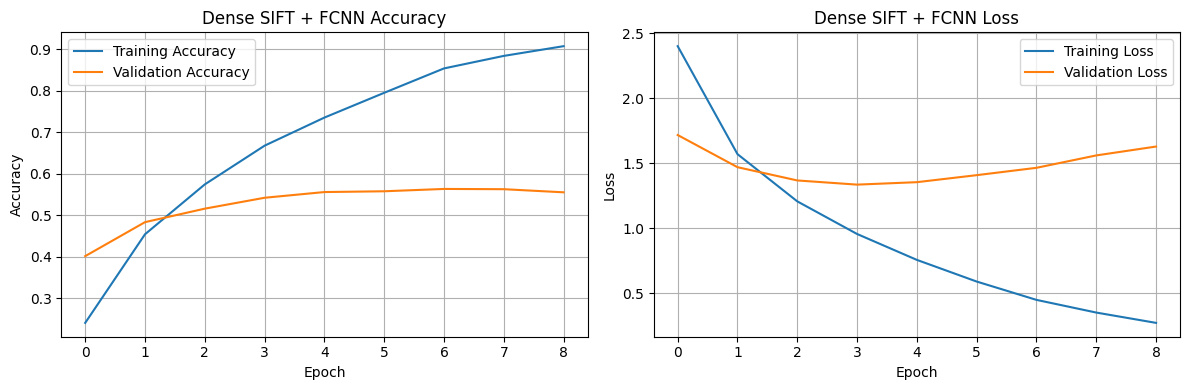

In [19]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(
    history_dense_sift_fcnn.history["accuracy"],
    label="Training Accuracy"
)
plt.plot(
    history_dense_sift_fcnn.history["val_accuracy"],
    label="Validation Accuracy"
)
plt.title("Dense SIFT + FCNN Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(
    history_dense_sift_fcnn.history["loss"],
    label="Training Loss"
)
plt.plot(
    history_dense_sift_fcnn.history["val_loss"],
    label="Validation Loss"
)
plt.title("Dense SIFT + FCNN Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

## 14. Classification Report and Confusion Matrix

63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step
              precision    recall  f1-score   support

    airplane       0.50      0.54      0.52       196
  automobile       0.67      0.71      0.69       198
        bird       0.36      0.39      0.37       195
         cat       0.35      0.20      0.26       199
        deer       0.51      0.44      0.47       198
         dog       0.43      0.45      0.44       185
        frog       0.62      0.73      0.67       216
       horse       0.64      0.62      0.63       193
        ship       0.59      0.67      0.63       217
       truck       0.66      0.66      0.66       203

    accuracy                           0.54      2000
   macro avg       0.53      0.54      0.53      2000
weighted avg       0.54      0.54      0.54      2000



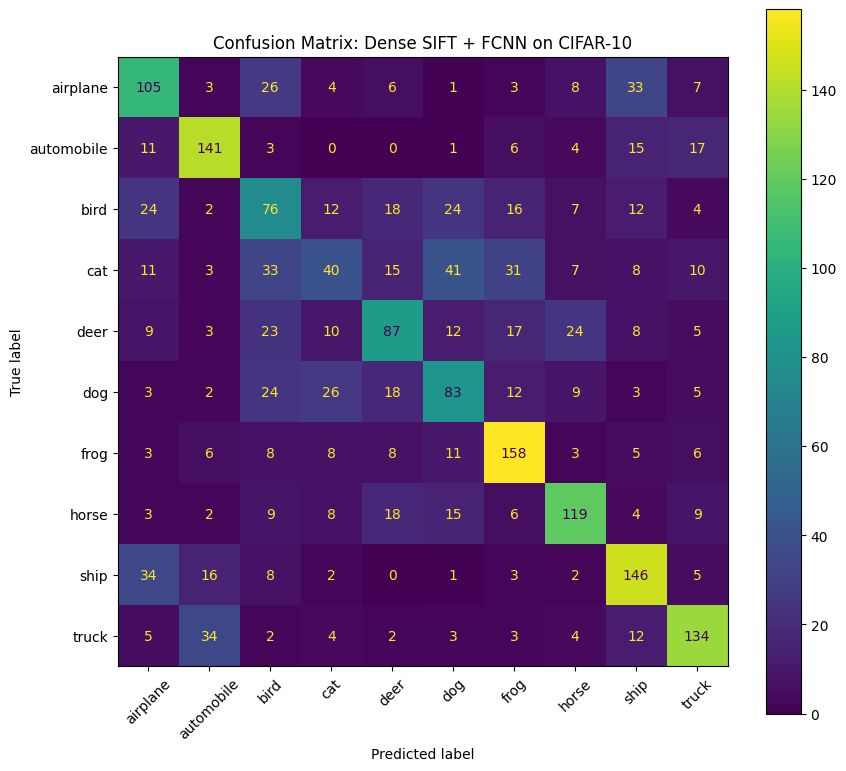

In [21]:
y_pred_prob = updated_dense_sift_fcnn.predict(
    x_test_dense_sift_scaled
)

y_pred_classes = np.argmax(y_pred_prob, axis=1)

print(
    classification_report(
        y_test_work,
        y_pred_classes,
        target_names=class_names
    )
)

cm = confusion_matrix(
    y_test_work,
    y_pred_classes
)

display = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

fig, ax = plt.subplots(figsize=(9, 8))

display.plot(
    ax=ax,
    xticks_rotation=45,
    values_format="d"
)

plt.title("Confusion Matrix: Dense SIFT + FCNN on CIFAR-10")
plt.tight_layout()
plt.show()

## 15 Compare Results with Previous Models

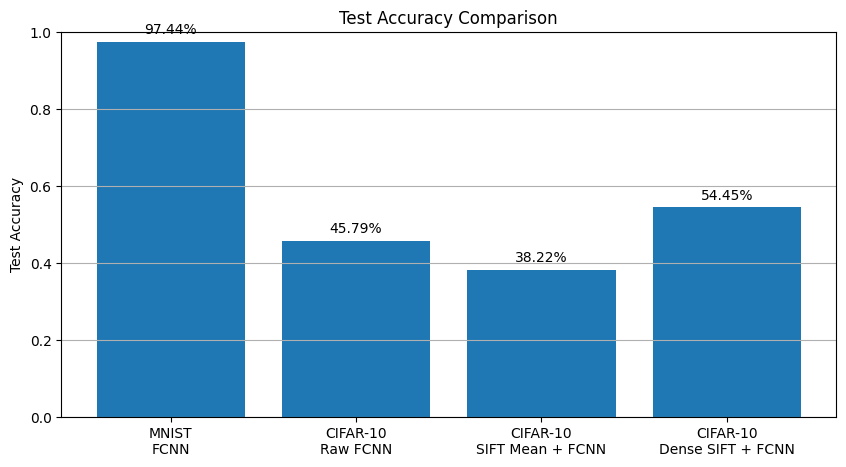

MNIST FCNN Accuracy: 0.9744
CIFAR-10 Raw Pixel FCNN Accuracy: 0.4579
CIFAR-10 SIFT Mean + FCNN Accuracy: 0.3822
CIFAR-10 Dense SIFT + FCNN Accuracy: 0.5444999933242798


In [22]:
mnist_fcnn_accuracy = 0.9744
cifar_raw_fcnn_accuracy = 0.4579
cifar_sift_mean_fcnn_accuracy = 0.3822
cifar_dense_sift_fcnn_accuracy = dense_sift_test_accuracy

models = [
    "MNIST\nFCNN",
    "CIFAR-10\nRaw FCNN",
    "CIFAR-10\nSIFT Mean + FCNN",
    "CIFAR-10\nDense SIFT + FCNN"
]

accuracies = [
    mnist_fcnn_accuracy,
    cifar_raw_fcnn_accuracy,
    cifar_sift_mean_fcnn_accuracy,
    cifar_dense_sift_fcnn_accuracy
]

plt.figure(figsize=(10, 5))

plt.bar(models, accuracies)

plt.title("Test Accuracy Comparison")
plt.ylabel("Test Accuracy")
plt.ylim(0, 1)

for i, value in enumerate(accuracies):
    plt.text(
        i,
        value + 0.02,
        f"{value:.2%}",
        ha="center"
    )

plt.grid(axis="y")
plt.show()

print("MNIST FCNN Accuracy:", mnist_fcnn_accuracy)
print("CIFAR-10 Raw Pixel FCNN Accuracy:", cifar_raw_fcnn_accuracy)
print("CIFAR-10 SIFT Mean + FCNN Accuracy:", cifar_sift_mean_fcnn_accuracy)
print("CIFAR-10 Dense SIFT + FCNN Accuracy:", cifar_dense_sift_fcnn_accuracy)

## 12. Final Short Explanation
Final Explanation:

In the previous SIFT + FCNN model, each CIFAR-10 image was represented
by taking the mean of its SIFT descriptors. This produced a single
128-dimensional feature vector.

However, this approach lost important spatial information and color
information. Also, standard SIFT depends on detected keypoints, which
may not be reliable for very small CIFAR-10 images.

In this updated version, the feature extraction part was improved using:

1. Dense SIFT:
   SIFT descriptors are extracted from a regular grid over the image.

2. RootSIFT:
   SIFT descriptors are normalized to improve feature representation.

3. Bag of Visual Words:
   Local descriptors are clustered into visual words using MiniBatchKMeans.

4. Spatial Pyramid:
   The image is divided into 2x2 regions so that some spatial information
   is preserved.

5. Color Histogram:
   Since SIFT uses grayscale images, RGB color histograms are added to
   include color information.

The FCNN classifier is still used at the end, but the input features are
now stronger than the previous mean-pooled SIFT features.

This updated experiment shows that better handcrafted feature extraction
can improve CIFAR-10 classification performance. However, the process is
still manually designed. This creates a natural transition to CNNs, where
feature extraction is learned automatically through convolutional filters.